# Préparation des données et Entrainement du modèle

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_validate
from sklearn import svm
import joblib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.naive_bayes import GaussianNB

In [3]:
df = pd.read_csv("../data/asl_dataset.csv")
X = df.drop(["label","depth"], axis=1).to_numpy(dtype=np.float32)
y = df["label"].to_numpy(dtype=int)
depth = df["depth"].to_numpy(dtype=np.float32)

In [4]:
df.describe()

,p0,p1,p2,p3,p4,p5,p6,p7,p8,p9,...,p34,p35,p36,p37,p38,p39,p40,p41,depth,label
count,10400.000000,10400.000000,10400.000000,10400.000000,10400.000000,10400.000000,10400.000000,10400.000000,10400.000000,10400.000000,...,10400.000000,10400.000000,10400.000000,10400.000000,10400.000000,10400.000000,10400.000000,10400.000000,10400.000000,10400.000000
mean,0.537263,0.709700,0.612991,0.663676,0.651906,0.588666,0.627005,0.530820,0.587466,0.501228,...,0.433420,0.522417,0.428479,0.479031,0.447207,0.504544,0.460981,0.524995,-0.077012,12.500000
std,0.179115,0.168293,0.158980,0.157750,0.151654,0.151434,0.166099,0.156748,0.191793,0.167884,...,0.164825,0.156727,0.169479,0.160139,0.177315,0.173804,0.186028,0.191696,0.066371,7.500361
min,0.009729,-0.051224,0.095031,-0.003801,0.051512,0.077153,0.061904,0.112318,0.018379,0.058529,...,-0.017366,0.015412,-0.017342,0.016451,-0.008597,0.009197,-0.016580,0.010278,-0.641923,0.000000
25%,0.406174,0.598970,0.501711,0.555653,0.546196,0.480589,0.509710,0.418276,0.446303,0.380936,...,0.311072,0.414533,0.300190,0.362156,0.311783,0.374401,0.320702,0.386151,-0.101690,6.000000
50%,0.534234,0.729945,0.617201,0.679966,0.660846,0.600628,0.636658,0.532908,0.590643,0.498947,...,0.432038,0.525233,0.424773,0.476635,0.443502,0.507772,0.457494,0.537374,-0.064020,12.500000
75%,0.671686,0.842024,0.733310,0.783651,0.768366,0.701172,0.756147,0.646734,0.738064,0.620261,...,0.553193,0.636958,0.554357,0.597130,0.582434,0.640404,0.601818,0.677507,-0.040609,19.000000
max,1.105940,1.159120,1.061370,1.088809,0.976399,0.936329,0.999459,0.962740,1.021798,0.985203,...,1.016402,1.026500,1.006571,1.016207,1.005224,1.002578,1.006126,1.000544,0.303004,25.000000


## Pré-processing
Ici les 42 features correspondent a la position (x,y) de chacun des 21 points pris sur la main.
Les valeurs correspondent à la position dite 'absolue' des points sur l'image, or nous ne souhaitons pas determiner le signe à partir de la position de la main sur l'ecran mais plutot à partir de la position dite 'relative' de chaque point par rapport au centre de gravité de la main.
Dans la suite on considerera que le centre de gravité correspond à au point moyen de la main.
Pour avoir ces coordonnées relatives on soustrait le centre de gravité de la main à chacun de ses points. 

De plus, dans toutes les images du dataset, la main se trouve a la meme distance de la camera. Si la main s'éloigne de la camera alors on se retrouve avec un probleme car la distance entre les points diminue. On décide donc de 'normaliser' en divisant chaque coordonnée par la distance entre le poignet et le majeur.

Dans ce dataset, toutes les images correspondent à la même main. En entrainant le modele de cette maniere, on pourrait donc rencontrer des differences de prédiction pour le même signe suivant si on le fait avec la main gauche ou droite.
On décide donc dupliquer chaque ligne du dataset, en inversant les coordonnée sur l'axe X.

In [5]:
def distance(X1, X2):
    return np.linalg.norm(X1-X2)

In [6]:
X_inter = X.reshape(X.shape[0],21,2)
X_processed = np.zeros((2*X.shape[0],42))
cnt = 0
for i in range(X_inter.shape[0]):
    # Absolue -> Relative & Normalisation
    dist_norm = distance(X_inter[i,0],X_inter[i,9])
    mean = X_inter[i].mean(axis=0)
    X_i = (X_inter[i] - mean)/dist_norm
    X_processed[cnt] = X_i.reshape(42) 

    # Inversion Gauche/Droite
    X_i[:,0]*=-1
    X_processed[cnt+1] = X_i.reshape(42)

    cnt+=2

y_processed = np.zeros(2*y.shape[0])
cnt = 0
for i in range (y.shape[0]):
    y_processed[cnt] = y[i]
    y_processed[cnt+1] = y[i]
    cnt+=2

Nous allons tester les performances d'un modele sur les données brutes avec les positions absolue des points, puis avec les position relative au centre de gravité.

In [7]:
# Coordonnées Absolues
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = svm.SVC()
clf.fit(X_train, y_train)

print(f"Performance sur l'ensemble d'entrainement : {clf.score(X_train, y_train)}")
print(f"Performance sur l'ensemble de test : {clf.score(X_test, y_test)}")

Performance sur l'ensemble d'entrainement : 0.9449519230769231
Performance sur l'ensemble de test : 0.91875


In [8]:
# Coordonnées Relative
X_train, X_test, y_train, y_test = train_test_split(X_processed, y_processed, test_size=0.2, random_state=42)

clf = svm.SVC()
clf.fit(X_train, y_train)

print(f"Performance sur l'ensemble d'entrainement : {clf.score(X_train, y_train)}")
print(f"Performance sur l'ensemble de test : {clf.score(X_test, y_test)}")

Performance sur l'ensemble d'entrainement : 0.9620192307692308
Performance sur l'ensemble de test : 0.9584134615384615


Il y a une très legere amelioration sur les coordonnées relatives, les resultats du premier modèle ne sont pas très representatif car la main se trouve approximativement au centre dans toutes les image et avec la même profondeur. 

In [9]:
X = X_processed
y = y_processed

## Train-Test Split
Le split ne peut pas être éffectué de manière aléatoire. Étant donnée que chaque main est dupliqué et inversé, il faut ne faudrait pas que deux lignes correspondant à la même main soient séparées, donc que l'une soit dans l'ensemble de test et que l'autre soit dans celui de train.
On fait donc le split manuellement.

In [10]:
test_size = 0.2
N = X.shape[0]
N_trainval = int(N*(1-test_size))
N_test = int(N*test_size)

N_per_class = int(N/26)
N_trainval_per_class = int(N_trainval/26)
N_test_per_class = int(N_test/26)


X_trainval = np.zeros((N_trainval,X.shape[1]))
X_test = np.zeros((N_test,X.shape[1]))
y_trainval = np.zeros(N_trainval)
y_test = np.zeros(N_test)

cnt = 0
cnt_trainval = 0
cnt_test = 0
for i in range(26):
    for xtrainval, ytrainval in zip(X[cnt:cnt+N_trainval_per_class], y[cnt:cnt+N_trainval_per_class]):
        X_trainval[cnt_trainval]=xtrainval
        y_trainval[cnt_trainval]=ytrainval
        cnt+=1
        cnt_trainval+=1
    for xtest, ytest in zip(X[cnt:cnt+N_test_per_class], y[cnt:cnt+N_test_per_class]):
        X_test[cnt_test]=xtest
        y_test[cnt_test]=ytest
        cnt+=1
        cnt_test+=1   

X_trainval.shape, X_test.shape

((16640, 42), (4160, 42))

## Entrainement des modèles

### SVC
Commençons par entrainer un modèle de classification multi-classe. Le SVC

In [22]:
def plot_CV(trainScore, validScore, plage_valeur_hyperparametre, nombreDePlisDeCV):
    plt.figure() 
    plt.errorbar(plage_valeur_hyperparametre, np.mean(trainScore,axis=1),label= "train score",yerr=np.std(trainScore,axis=1))
    plt.errorbar(plage_valeur_hyperparametre, np.mean(validScore,axis=1),label= "valid score",yerr=np.std(validScore,axis=1)/nombreDePlisDeCV, ls='--')
    plt.xlabel("alpha")
    plt.ylabel("scores")
    plt.legend()
    plt.semilogx(base = 2)

In [28]:
nb_valeurs = 5
val_c = np.logspace(1,nb_valeurs,nb_valeurs,base = 2)
nbPlisCV = 5
train_score = np.zeros((nb_valeurs,nbPlisCV))
test_score = np.zeros((nb_valeurs,nbPlisCV))

for i,C in enumerate(val_c) :
    clf = svm.SVC(C=int(C))

    CV = cross_validate(clf, X_trainval, y_trainval, cv = nbPlisCV, return_train_score=True)
    
    train_score[i] = CV['train_score']
    test_score[i] = CV['test_score']
        
    #print(f"Performance sur l'ensemble d'entrainement : {clf.score(X_train, y_train)}")
    #print(f"Performance sur l'ensemble de test : {clf.score(X_test, y_test)}")

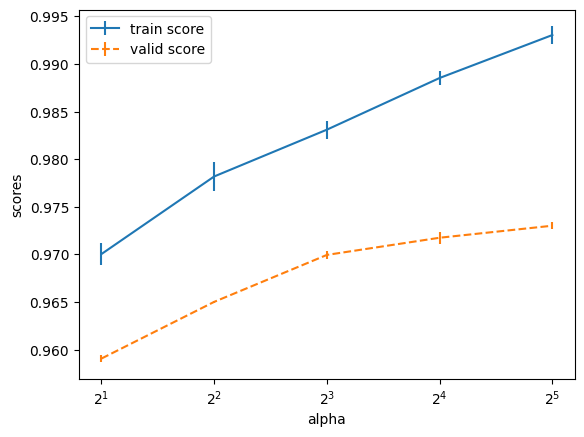

In [24]:
plot_CV(train_score, test_score, val_c, nbPlisCV)

In [11]:
clf = svm.SVC(C=2, probability = True)
clf.fit(X_trainval, y_trainval)

print(f"Performance sur l'ensemble d'entrainement : {clf.score(X_trainval, y_trainval)}")
print(f"Performance sur l'ensemble de test : {clf.score(X_test, y_test)}")

Performance sur l'ensemble d'entrainement : 0.971514423076923
Performance sur l'ensemble de test : 0.9639423076923077


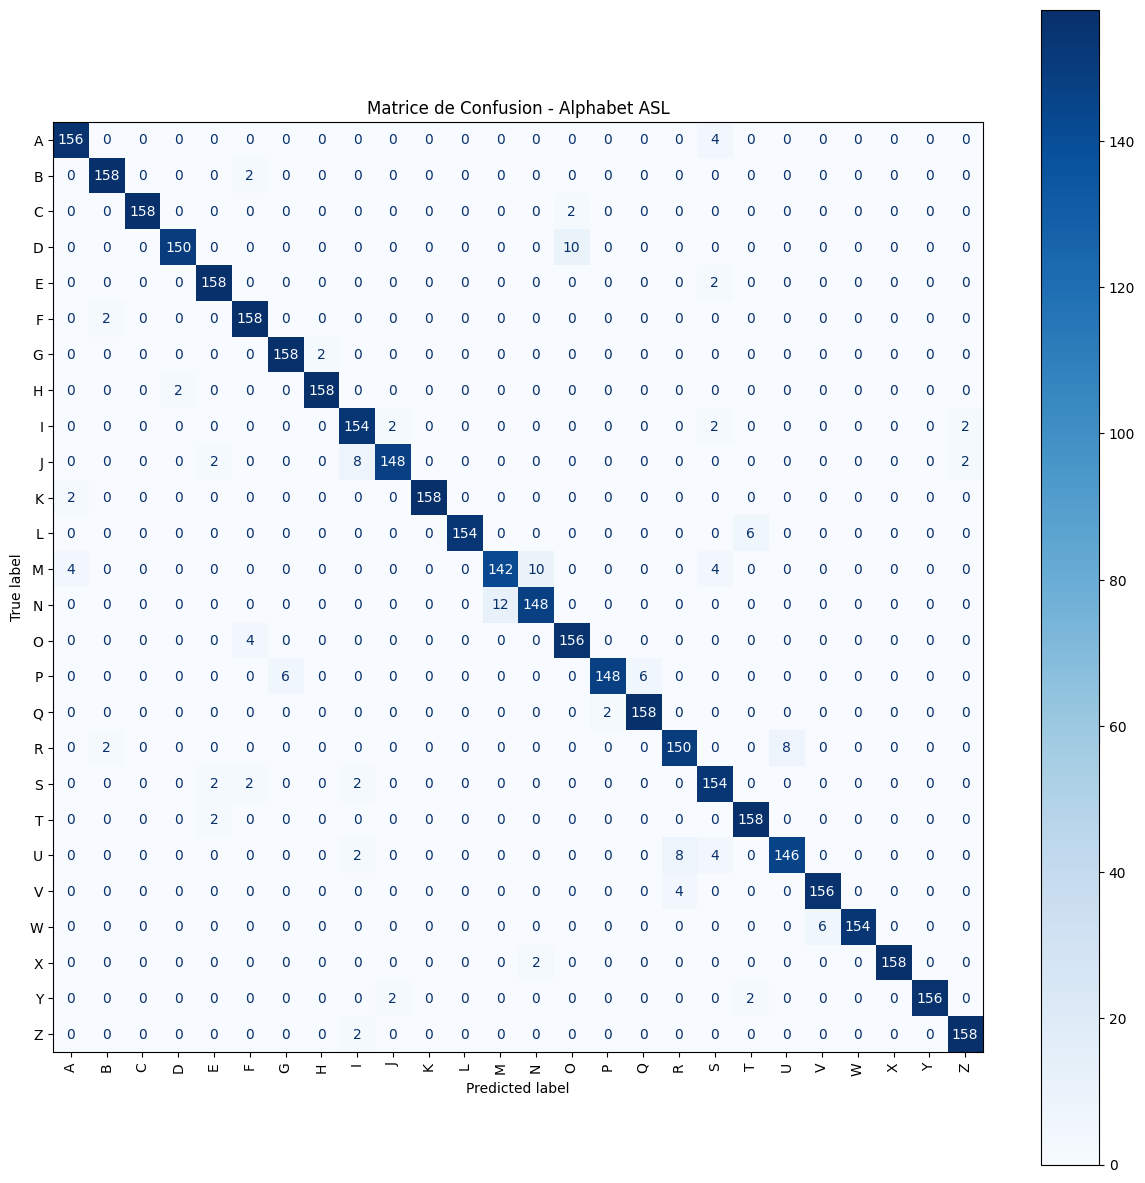

In [14]:
labels = [chr(65+i) for i in range(26)]
y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(15, 15))

cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

cm_display.plot(cmap='Blues', ax=ax, xticks_rotation='vertical')

plt.title("Matrice de Confusion - Alphabet ASL")
plt.show()

Le modèle semble bien differencier les signes, on remarque cependant de légères confusions, notamment entre le **N** et le **M**, ainsi qu'entre le **D** et **O**.

In [ ]:
joblib.dump(clf, "../models/asl_model.pkl")

['asl_model.pkl']

### Modèle Bayesien
Essayons maintenant avec un modèle probabiliste bayésien.

#### Non supervisé
Observons d'abord la distribution de nos données, pour choisir une loi **

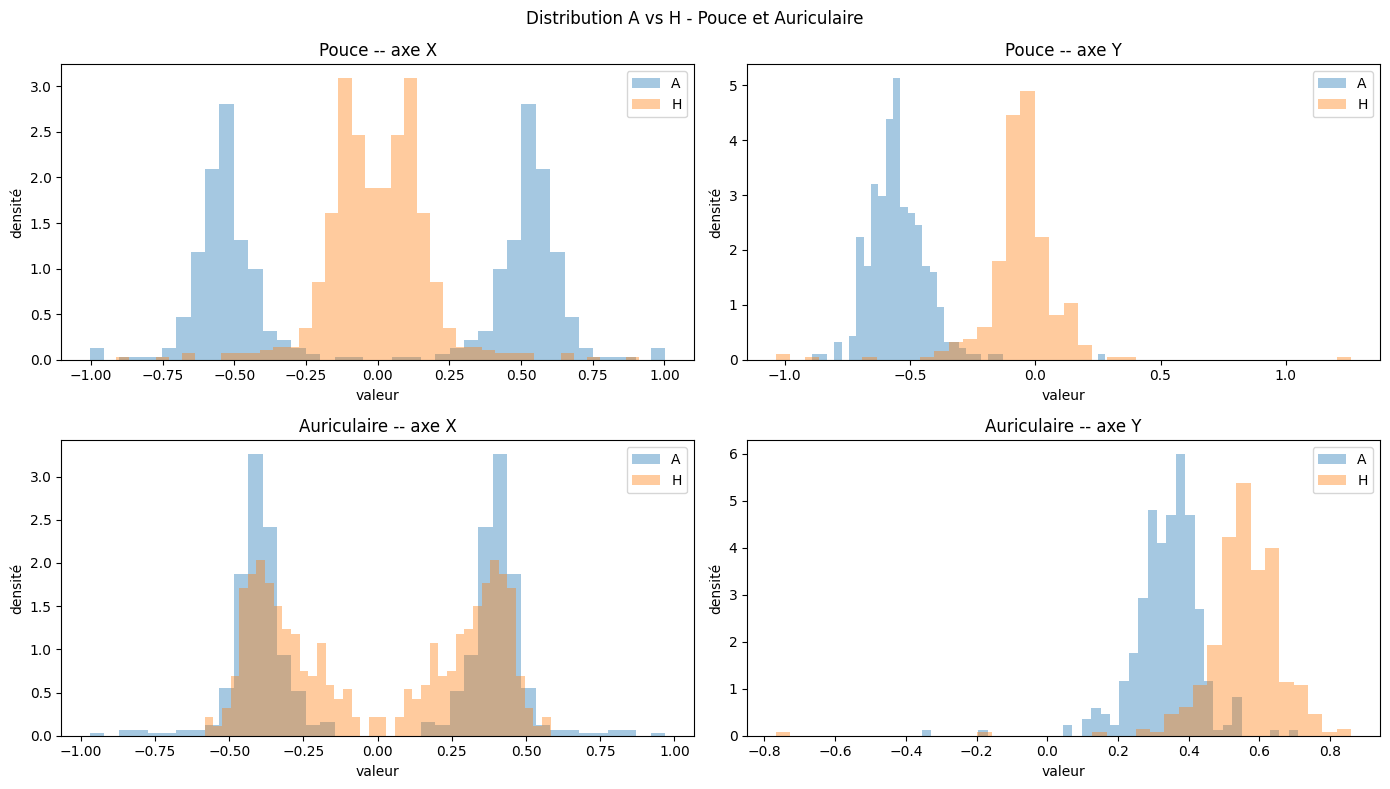

In [40]:
label = {chr(65+i): i for i in range(26)}
cmap = plt.get_cmap("tab10")
lettres = ['A','H']

mask_label = [(y_trainval == label[l], l, cmap(i)) for i,l in enumerate(lettres)]

points = {"Pouce -- axe X": 8,"Pouce -- axe Y": 9,"Auriculaire -- axe X": 40,"Auriculaire -- axe Y": 41}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (nom, feat_idx) in zip(axes.flat, points.items()):
    for mask, label, color in mask_label:
        data = X_trainval[mask, feat_idx]
        ax.hist(data, bins=40, density=True, alpha=0.4, color=color, label=label)

    ax.set_title(nom)
    ax.set_xlabel("valeur")
    ax.set_ylabel("densité")
    ax.legend()

plt.suptitle("Distribution A vs H - Pouce et Auriculaire")
plt.tight_layout()
plt.show()

On remarque deux choses :

La premiere, c'est que les données semblent suivre une loi normale.

La seconde, c'est que sur l'axe X, la courbe est symetrique par rapport à 0, c'est car on a dupliqué chaque ligne pour chaque classe, en inversant l'axe X. Cela signifie que les deux courbes en cloches, des distribution de l'axe X, correspondent aux distributions de la main gauche, ainsi que de la main droite. 
Cela ouvre la porte à non seulement la prédiction du signe, mais aussi à la prédiction de la direction (gauche/droite) de la main. Pour ce faire, il faudrait donc passer de 26 à 52 classes.

#### Naive Bayes
Commençons par une approche naive, meme si l'on sait les données ne sont pas indépendante. Il existe plusieurs correlation que nous verrons par la suite

In [47]:
clf_gnb = GaussianNB()
clf_gnb.fit(X_trainval, y_trainval)

print(f"Performance sur l'ensemble d'entrainement : {clf_gnb.score(X_trainval, y_trainval)}")
print(f"Performance sur l'ensemble de test : {clf_gnb.score(X_test, y_test)}")

Performance sur l'ensemble d'entrainement : 0.8361778846153847
Performance sur l'ensemble de test : 0.8418269230769231


#### (pas)Naive Bayes
On sais qu'il existe une correllation entre les données, par exemple toutes les articulation d'un même doigt le sont, les positions des doigts entre eux, par exemple entre le majeur et l'index.